## ML I Demo II

## Compare K-means with different data

This section builds four synthetic datasets to show when K‑means works and when it struggles:

Mixture of Gaussian blobs (roughly spherical, equal variance): K‑means usually performs well.

Unevenly sized blobs (500 vs. 100 vs. 10 points): K‑means can bias centroids toward larger groups and split/merge clusters incorrectly.

Anisotropic blobs: we apply a linear transformation with a 2×2 matrix to stretch/rotate blobs, creating elliptical clusters. K‑means assumes spherical clusters, so boundaries become sub‑optimal.

Unequal variance: each blob has a different standard deviation (cluster_std=[1.0, 2.5, 0.5]), so one cluster is much wider/narrower than others. K‑means’ equal‑variance assumption can misplace centroids and decision boundaries.

Lessons to be learnt: K‑means partitions by Euclidean distance and implicitly favors spherical, similar‑sized, similar‑variance clusters. When those assumptions break (shape, variance, size), performance degrades. The figure titled “Ground truth clusters” gives the reference labels we aim to recover.

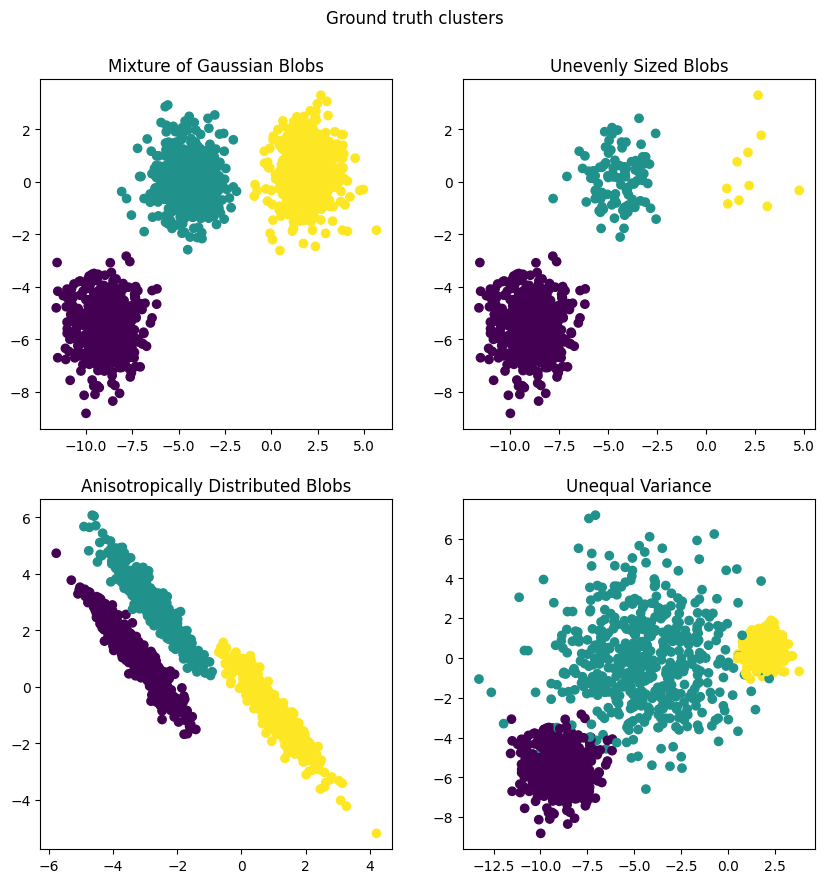

In [ ]:
import numpy as np

from sklearn.datasets import make_blobs

n_samples = 1500
random_state = 170
transformation = [[0.60834549, -0.63667341], [-0.40887718, 0.85253229]]

X, y = make_blobs(n_samples=n_samples, random_state=random_state)
X_aniso = np.dot(X, transformation)  # Anisotropic blobs
X_varied, y_varied = make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)  # Unequal variance
X_filtered = np.vstack(
    (X[y == 0][:500], X[y == 1][:100], X[y == 2][:10])
)  # Unevenly sized blobs
y_filtered = [0] * 500 + [1] * 100 + [2] * 10

import matplotlib.pyplot as plt

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(10, 10))

axs[0, 0].scatter(X[:, 0], X[:, 1], c=y)
axs[0, 0].set_title("Mixture of Gaussian Blobs")

axs[0, 1].scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_filtered)
axs[0, 1].set_title("Unevenly Sized Blobs")

axs[1, 0].scatter(X_aniso[:, 0], X_aniso[:, 1], c=y)
axs[1, 0].set_title("Anisotropically Distributed Blobs") #properties vary with the direction: eliptic blobs

axs[1, 1].scatter(X_varied[:, 0], X_varied[:, 1], c=y_varied)
axs[1, 1].set_title("Unequal Variance")

plt.suptitle("Ground truth clusters").set_y(0.95)
plt.show()

### Wrong options

What goes wrong with naive choices?
Here we intentionally apply K‑means in non‑optimal ways to visualize typical failure modes:

Wrong number of clusters (n_clusters=2 on a 3‑blob dataset): Even with ideal spherical blobs, a mismatched k forces K‑means to merge or split structures incorrectly.

Unevenly sized blobs: A single k=3 run can assign boundaries that favor larger blobs, sometimes splitting them while swallowing small clusters. Initialization and size imbalance exacerbate this.

Anisotropic blobs (elliptical): K‑means uses circular Voronoi regions; it cannot align with elongated shapes, producing jagged, non‑elliptical partitions.

Unequal variance: The wide cluster’s points are farther from its centroid on average; K‑means often over‑assigns points to the wide cluster or misplaces boundaries.

Takeaway: K‑means is fast and popular, but if your data are anisotropic, heteroscedastic, or imbalanced, you should (a) verify k, (b) use multiple initializations, or (c) consider other algorithms. The plot titled “Unexpected KMeans clusters” shows these pathologies.

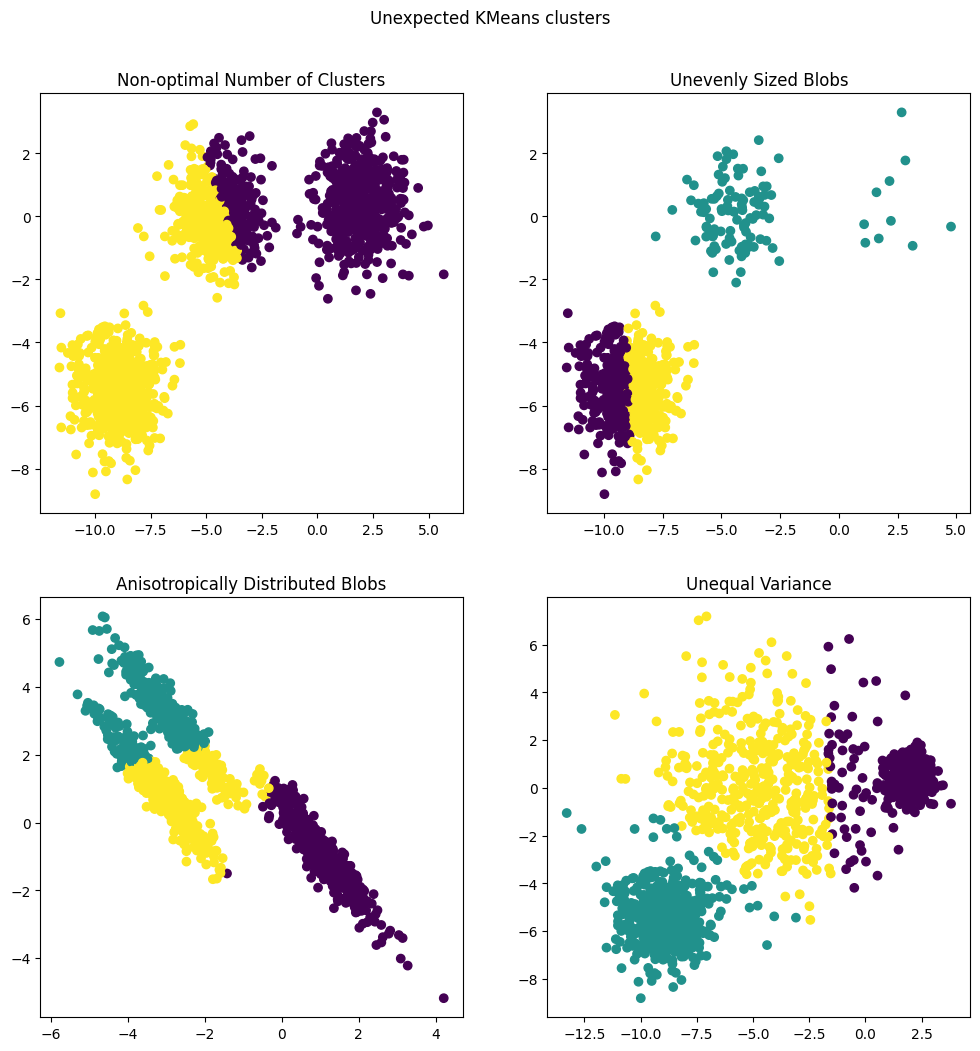

In [ ]:
from sklearn.cluster import KMeans

common_params = {
    "n_init": "auto",
    "random_state": random_state,
}

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 12))

y_pred = KMeans(n_clusters=2, **common_params).fit_predict(X)
axs[0, 0].scatter(X[:, 0], X[:, 1], c=y_pred)
axs[0, 0].set_title("Non-optimal Number of Clusters")

y_pred = KMeans(n_clusters=3, **common_params).fit_predict(X_filtered)
axs[0, 1].scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_pred)
axs[0, 1].set_title("Unevenly Sized Blobs")

y_pred = KMeans(n_clusters=3, **common_params).fit_predict(X_aniso)
axs[1, 0].scatter(X_aniso[:, 0], X_aniso[:, 1], c=y_pred)
axs[1, 0].set_title("Anisotropically Distributed Blobs")

y_pred = KMeans(n_clusters=3, **common_params).fit_predict(X_varied)
axs[1, 1].scatter(X_varied[:, 0], X_varied[:, 1], c=y_pred)
axs[1, 1].set_title("Unequal Variance")

plt.suptitle("Unexpected KMeans clusters").set_y(0.95)
plt.show()

### Solutions

Simply setting n_clusters=3 on the 3‑blob dataset yields the expected partition. In practice, you can select k via:

Elbow method (inertia vs. k),
Silhouette score (mean silhouette vs. k),
Information criteria with probabilistic models (BIC/AIC for GMMs).
Here, we demonstrate the simplest case: choose k to match the underlying structure. The figure “Optimal Number of Clusters” shows the corrected result. [K-means wi...erent data | HTML]

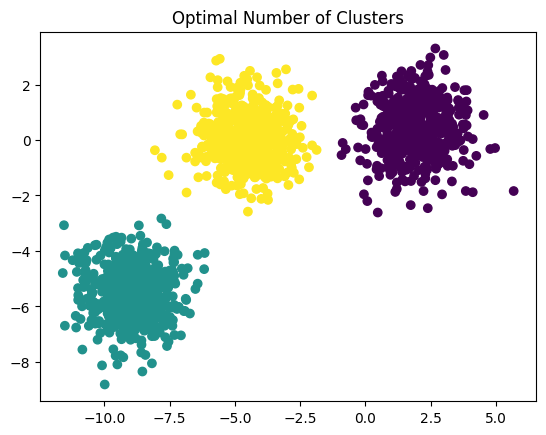

In [ ]:
# We simply choose a different number for k

y_pred = KMeans(n_clusters=3, **common_params).fit_predict(X)
plt.scatter(X[:, 0], X[:, 1], c=y_pred)
plt.title("Optimal Number of Clusters")
plt.show()

Fix #2 — Use multiple initializations to avoid bad local minima.
K‑means can converge to different solutions depending on the initial seeds. Increasing n_init (e.g., n_init=10) runs K‑means multiple times with different initializations and keeps the solution with the lowest inertia. This is especially helpful with unevenly sized blobs, where an unlucky initialization can split/merge clusters poorly. The plot “Unevenly Sized Blobs with several initializations” illustrates the improvement.

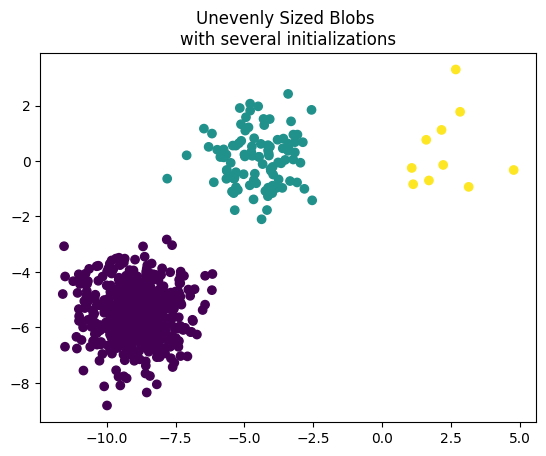

In [ ]:
# We run several initializations and the one with lowest Inertia is chosen

y_pred = KMeans(n_clusters=3, n_init=10, random_state=random_state).fit_predict(
    X_filtered
)
plt.scatter(X_filtered[:, 0], X_filtered[:, 1], c=y_pred)
plt.title("Unevenly Sized Blobs \nwith several initializations")
plt.show()

Fix #3 — Use an algorithm that models shape and variance.

For anisotropic and unequal variance clusters, Gaussian Mixture Models (GMMs) fit Gaussian components with full covariances, naturally capturing elliptical shapes and varying spreads. We use GaussianMixture(n_components=3) to recover cluster structure where K‑means struggles. The figure “Gaussian mixture clusters” shows improved partitions for both the transformed (elliptical) blobs and the unequal‑variance blobs.

Why GMM helps:
Soft assignments: Instead of a hard nearest‑centroid rule, GMMs assign probabilities to components.
Covariance modeling: Full covariance matrices rotate/scale ellipses to match data.
EM algorithm: Iteratively updates means, covariances, and mixture weights for better fit.

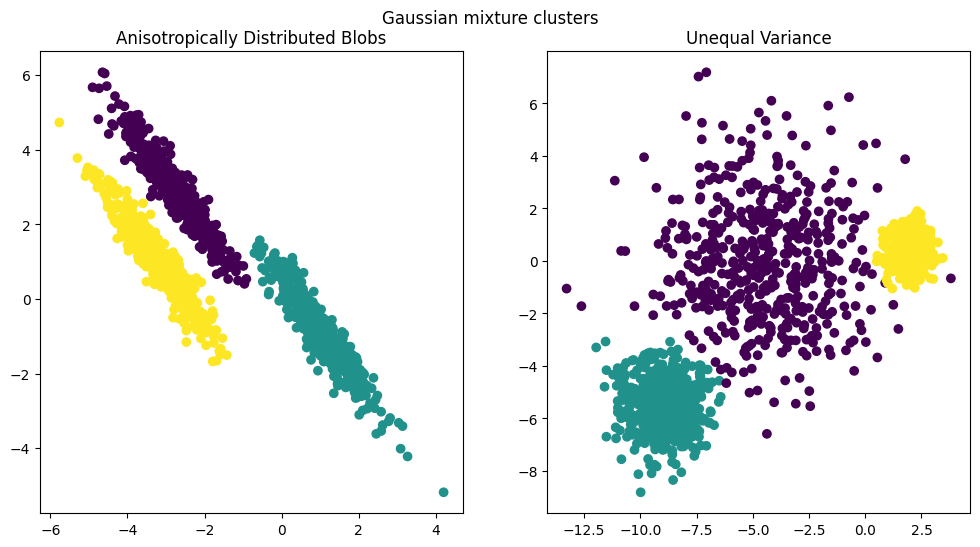

In [ ]:
# We need to use different algorithms, k-means is not efficient. In this case we use a Gaussian mixture one

from sklearn.mixture import GaussianMixture

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

y_pred = GaussianMixture(n_components=3).fit_predict(X_aniso)
ax1.scatter(X_aniso[:, 0], X_aniso[:, 1], c=y_pred)
ax1.set_title("Anisotropically Distributed Blobs")

y_pred = GaussianMixture(n_components=3).fit_predict(X_varied)
ax2.scatter(X_varied[:, 0], X_varied[:, 1], c=y_pred)
ax2.set_title("Unequal Variance")

plt.suptitle("Gaussian mixture clusters").set_y(0.95)
plt.show()

## When to use K‑means vs. alternatives

Use K‑means when clusters are roughly spherical, similar in size, and similar in variance.
Use multiple initializations (and k‑means++) to avoid poor local minima.
Consider GMMs (or DBSCAN/spectral clustering) when clusters are elliptical, heteroscedastic, or unevenly sized.
Always visualize and validate with metrics (inertia, silhouette) and, if possible, compare to ground truth.